In [ ]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
import tensorflow.keras.activations
from tensorflow.keras.layers import (
    Input,
    Dense,
    Embedding,
    Conv2D,
    SeparableConv2D,
    DepthwiseConv2D,
    Conv2DTranspose,
    MaxPooling2D,
    UpSampling2D,
    BatchNormalization,
    LayerNormalization,
    Dropout,
    Reshape,
    Flatten,
    Add,
    Multiply,
    Concatenate,
    MultiHeadAttention,
    Softmax,
    Activation
)

# Hyper parameters :

In [ ]:
config = {}
config["image_size"] = 256
config["num_layers"] = 9
config["hidden_dim"] = 256
config["key_dim"] = 64
config["mlp_dim"] = 512
config["num_heads"] = 4
config["dropout_rate"] = 0.1
config["patch_size"] = 16
config["num_patches"] = (config["image_size"]**2)//(config["patch_size"]**2)
config["num_channels"] = 1

# Model Arch. :

In [ ]:
def mlp(input, conf):
  x = Dense(conf["mlp_dim"], activation="gelu")(input)
  x = Dropout(conf["dropout_rate"])(x)
  x = Dense(conf["hidden_dim"])(x)
  x = Dropout(conf["dropout_rate"])(x)
  return x

def trasfromer_encoder(input, conf):
  skip_1 = input
  x = LayerNormalization()(input)
  x = MultiHeadAttention(conf["num_heads"], conf["key_dim"])(x, x)
  x = Add()([x, skip_1])
  skip_2 = x
  x = LayerNormalization()(x)
  x = mlp(x ,conf)
  x = Add()([x, skip_2])
  return x

def conv_block(x, num_filters, kernel_size=3):
  x = Conv2D(num_filters, kernel_size=kernel_size, padding="same")(x)
  x = BatchNormalization()(x)
  x = Activation("relu")(x)
  return x

def deconv_block(x, num_filters, stride=2, kernel_size=2):
  x = Conv2DTranspose(num_filters, kernel_size=kernel_size, strides=stride, padding="same")(x)
  return x

def bulid_2d_unetr(conf):
  input = Input(shape=(conf["num_patches"], conf["patch_size"]*conf["patch_size"]*conf["num_channels"]))
  print(input.shape)
  """ Patch + Position Embeddings """
  patched_embedded = Dense(conf["hidden_dim"])(input)
  print(patched_embedded.shape)
  position = tf.range(start=0, limit=conf["num_patches"], delta=1)
  print(position.shape)
  position_embedding = Embedding(input_dim=conf["num_patches"], output_dim=conf["hidden_dim"])(position)
  print(position_embedding.shape)
  embedded = patched_embedded + position_embedding

  skip_connections = []
  skip_conncections_indecies = [3, 6, 9]
  for i in range(conf["num_layers"]+1):
    x = trasfromer_encoder(embedded, conf)
    if i in skip_conncections_indecies:
      skip_connections.append(x)

  z3, z6, z9 = skip_connections
  print("z3 :",z3.shape)
  print("z6 :",z6.shape)
  print("z9 :",z9.shape)

  z0 = Reshape((conf["image_size"], conf["image_size"], conf["num_channels"]))(input)


  shape = (conf["image_size"]//conf["patch_size"] , conf["image_size"] //conf["patch_size"],conf["hidden_dim"])
  z3 = Reshape(shape)(z3)
  print("z3 :",z3.shape)
  z6 = Reshape(shape)(z6)
  z9 = Reshape(shape)(z9)

  z6 = deconv_block(z6, 128)
  z6 = conv_block(z6, 128)
  x = deconv_block(z9, 128)
  x = Concatenate()([x, z6])

  z3 = deconv_block(z3, 128)
  z3 = conv_block(z3, 128)
  z3 = deconv_block(z3, 64)
  z3 = conv_block(z3, 64)
  x = conv_block(x, 128)
  x = conv_block(x, 128)
  x = deconv_block(x, 64)
  x = Concatenate()([x, z3])

  x = conv_block(x, 64)
  x = conv_block(x, 64)
  x = deconv_block(x, 32)
  x = conv_block(x, 32)
  x = deconv_block(x, 32)
  x = conv_block(x, 32)
  z0 = conv_block(z0, 32)
  z0 = conv_block(z0, 32)
  print("test")
  print("z0 shape: ", z0.shape)
  print("x shape: ", x.shape)
  x = Concatenate()([x, z0])

  x = conv_block(x, 32)
  x = conv_block(x, 32)

  output = Conv2D(4, kernel_size=1, padding="same", activation="softmax")(x)
  print("output shape: ", output.shape)

  return Model(input, output, name="UNETR_2D")



In [ ]:
  model = bulid_2d_unetr(config)
  model.summary()

(None, 256, 256)
(None, 256, 256)
(256,)
(256, 256)
z3 : (None, 256, 256)
z6 : (None, 256, 256)
z9 : (None, 256, 256)
z3 : (None, 16, 16, 256)
test
z0 shape:  (None, 256, 256, 32)
x shape:  (None, 256, 256, 32)
output shape:  (None, 256, 256, 4)


Model: "UNETR_2D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256, 256)  │     65,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 256, 256)  │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 256, 256)  │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 256, 512)  │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 256)  │        512 │ add_19[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 256, 256)  │    131,328 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 256, 256)  │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,063,652 (11.69 MB)

 Trainable params: 3,061,860 (11.68 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# CELL 1: Install libraries
# ============================================================
!pip install nibabel requests pandas -q
print("✓ Libraries ready")


✓ Libraries ready


In [ ]:
# ============================================================
# CELL 2: Download phenotypic CSV
# ============================================================
import urllib.request as request
import pandas as pd
import os

csv_path = '/content/Phenotypic_V1_0b_preprocessed1.csv'

if not os.path.exists(csv_path):
    print("Downloading phenotypic CSV...")
    request.urlretrieve(
        'https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Phenotypic_V1_0b_preprocessed1.csv',
        csv_path
    )
    print("✓ CSV downloaded")
else:
    print("✓ CSV already exists")

pheno = pd.read_csv(csv_path)
print(f"Total subjects in dataset: {len(pheno)}")
print(pheno[['FILE_ID', 'SITE_ID', 'DX_GROUP']].head())


✓ CSV downloaded
Total subjects in dataset: 1112
        FILE_ID SITE_ID  DX_GROUP
0   no_filename    PITT         1
1  Pitt_0050003    PITT         1
2  Pitt_0050004    PITT         1
3  Pitt_0050005    PITT         1
4  Pitt_0050006    PITT         1


In [ ]:
# ============================================================
# CELL 3: Download T1.mgz (raw brain MRI = model INPUT)
# ============================================================
import urllib.request as request
import pandas as pd
import os

csv_path = '/content/Phenotypic_V1_0b_preprocessed1.csv'
S3_PREFIX = 'https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative'

def download_t1(out_dir, max_subjects=10):
    os.makedirs(out_dir, exist_ok=True)
    pheno = pd.read_csv(csv_path)

    downloaded = 0
    failed = []

    for _, row in pheno.iterrows():
        if downloaded >= max_subjects:
            break
        file_id = row['FILE_ID']
        if file_id == 'no_filename':
            continue

        save_path = os.path.join(out_dir, f"{file_id}_T1.mgz")
        url       = f"{S3_PREFIX}/Outputs/freesurfer/5.1/{file_id}/mri/T1.mgz"

        if os.path.exists(save_path):
            print(f"✓ Already exists: {file_id}")
            downloaded += 1
            continue

        try:
            print(f"⬇ Downloading T1 ({downloaded+1}/{max_subjects}): {file_id}")
            request.urlretrieve(url, save_path)
            downloaded += 1
            print(f"  ✓ Done")
        except Exception as e:
            print(f"  ✗ Failed: {file_id} → {e}")
            failed.append(file_id)

    print(f"\n✅ Downloaded: {downloaded} | ❌ Failed: {len(failed)}")
    return failed

failed_t1 = download_t1('/content/abide_data', max_subjects=1)



⬇ Downloading T1 (1/1): Pitt_0050003
  ✓ Done

✅ Downloaded: 1 | ❌ Failed: 0


In [ ]:
# ============================================================
# CELL 4: Download ribbon.mgz + aseg.mgz (tissue labels)
# ============================================================
import urllib.request as request
import pandas as pd
import os

csv_path  = '/content/Phenotypic_V1_0b_preprocessed1.csv'
S3_PREFIX = 'https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative'

def download_labels(out_dir, max_subjects=10):
    os.makedirs(out_dir, exist_ok=True)
    pheno = pd.read_csv(csv_path)

    downloaded = 0
    failed = []

    for _, row in pheno.iterrows():
        if downloaded >= max_subjects:
            break
        file_id = row['FILE_ID']
        if file_id == 'no_filename':
            continue

        files_to_get = {
            'ribbon': f"{S3_PREFIX}/Outputs/freesurfer/5.1/{file_id}/mri/ribbon.mgz",
            'aseg'  : f"{S3_PREFIX}/Outputs/freesurfer/5.1/{file_id}/mri/aseg.mgz",
        }

        subject_ok = True
        for name, url in files_to_get.items():
            save_path = os.path.join(out_dir, f"{file_id}_{name}.mgz")
            if os.path.exists(save_path):
                print(f"✓ Already exists: {file_id}_{name}")
                continue
            try:
                print(f"⬇ Downloading {name} ({downloaded+1}/{max_subjects}): {file_id}")
                request.urlretrieve(url, save_path)
                print(f"  ✓ Done")
            except Exception as e:
                print(f"  ✗ Failed {name}: {file_id} → {e}")
                subject_ok = False
                failed.append(f"{file_id}_{name}")

        if subject_ok:
            downloaded += 1

    print(f"\n✅ Downloaded: {downloaded} subjects | ❌ Failed files: {len(failed)}")
    return failed

failed_labels = download_labels('/content/abide_labels', max_subjects=1)

⬇ Downloading ribbon (1/1): Pitt_0050003
  ✓ Done
⬇ Downloading aseg (1/1): Pitt_0050003
  ✓ Done

✅ Downloaded: 1 subjects | ❌ Failed files: 0


In [ ]:

# ============================================================
# CELL 5: Convert ribbon.mgz + aseg.mgz → 4-class mask
#   0 = Background
#   1 = CSF
#   2 = Gray Matter
#   3 = White Matter
# ============================================================
import nibabel as nib
import numpy as np
import os

def convert_to_4class(labels_dir, masks_dir, file_id):
    ribbon_path = os.path.join(labels_dir, f"{file_id}_ribbon.mgz")
    aseg_path   = os.path.join(labels_dir, f"{file_id}_aseg.mgz")

    ribbon = np.array(nib.load(ribbon_path).dataobj)
    aseg   = np.array(nib.load(aseg_path).dataobj)
    affine = nib.load(ribbon_path).affine

    mask = np.zeros_like(ribbon, dtype=np.uint8)

    # CSF from aseg
    for lbl in [4, 5, 14, 15, 24, 43, 44, 72]:
        mask[aseg == lbl] = 1

    # Gray Matter from ribbon
    mask[(ribbon == 3) | (ribbon == 42)] = 2

    # White Matter from ribbon
    mask[(ribbon == 2) | (ribbon == 41)] = 3

    out_path = os.path.join(masks_dir, f"{file_id}_mask4class.nii.gz")
    nib.save(nib.Nifti1Image(mask, affine), out_path)

    print(f"✓ {file_id}")
    print(f"   Background : {(mask==0).sum():>10,} voxels")
    print(f"   CSF        : {(mask==1).sum():>10,} voxels")
    print(f"   Gray Matter: {(mask==2).sum():>10,} voxels")
    print(f"   White Matter:{(mask==3).sum():>10,} voxels")

labels_dir = '/content/abide_labels'
masks_dir  = '/content/abide_masks'
os.makedirs(masks_dir, exist_ok=True)

for fname in sorted(os.listdir(labels_dir)):
    if fname.endswith('_ribbon.mgz'):
        file_id   = fname.replace('_ribbon.mgz', '')
        aseg_path = os.path.join(labels_dir, f"{file_id}_aseg.mgz")
        if not os.path.exists(aseg_path):
            print(f"✗ Missing aseg for {file_id}, skipping")
            continue
        try:
            convert_to_4class(labels_dir, masks_dir, file_id)
        except Exception as e:
            print(f"✗ Failed {file_id}: {e}")

print("\nAll masks created!")


✓ Pitt_0050003
   Background : 15,717,561 voxels
   CSF        :      2,353 voxels
   Gray Matter:    487,983 voxels
   White Matter:   569,319 voxels

All masks created!


150
256
Shape: (np.int32(256), np.int32(256), np.int32(256))


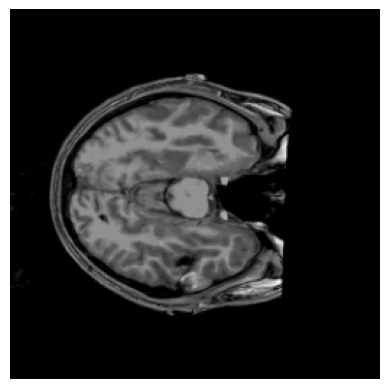

Shape: (np.int32(256), np.int32(256), np.int32(256))
Data Shape: (256, 256, 256)
Voxel size: (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type: uint8
55543
8
5807
4178
Shape: True


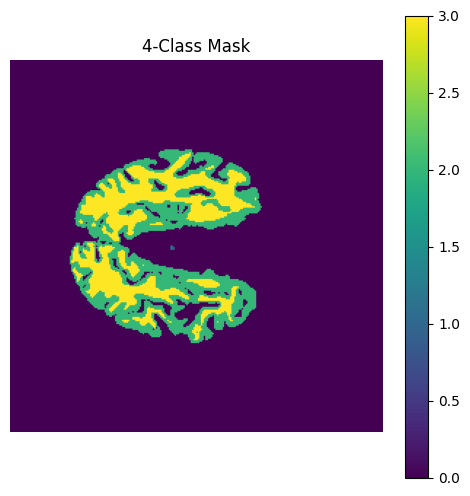

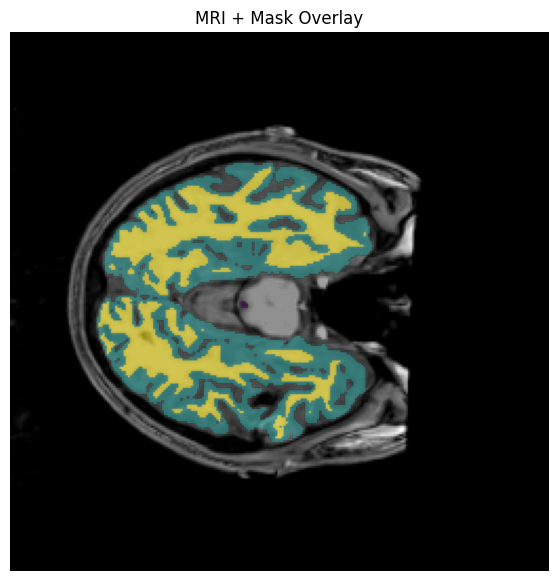

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

path = "/content/abide_data/Pitt_0050003_T1.mgz"

raw_mri = nib.load(path)
raw_data = raw_mri.get_fdata()
y = 150

print(y)
print(raw_data.shape[0])
print("Shape:", raw_mri.shape)

plt.imshow(raw_data[:, y, :], cmap="gray")
plt.axis("off")
plt.show()

print("Shape:", raw_mri.shape)
print("Data Shape:", raw_data.shape)
print("Voxel size:", raw_mri.header.get_zooms())
print("Data type:", raw_mri.get_data_dtype())



mask = nib.load(
    "/content/abide_masks/Pitt_0050003_mask4class.nii.gz"
)

data = mask.get_fdata()

print(np.sum(data[:,y,:]==0))
print(np.sum(data[:,y,:]==1))
print(np.sum(data[:,y,:]==2))
print(np.sum(data[:,y,:]==3))

print("Shape:", data.shape==(256, 256, 256))

plt.figure(figsize=(6,6))
plt.imshow(data[:,y,:])
plt.colorbar()
plt.title("4-Class Mask")
plt.axis("off")
plt.show()

print()


plt.figure(figsize=(7,7))

plt.imshow(raw_data[:, y, :], cmap="gray")
mask_no_bg = np.ma.masked_where(data[:, y, :] == 0, data[:, y, :])
plt.imshow(mask_no_bg, alpha=0.6)

plt.axis("off")
plt.title("MRI + Mask Overlay")

plt.show()

In [ ]:
# ============================================================
# CELL 1 of 2 — Extract 2D Y-axis slices and save as .npy
# ============================================================
#
# For every downloaded subject:
#   1. Loads T1.mgz + its 4-class mask.
#   2. Iterates over every Y-axis slice: volume[:, y, :]
#   3. Skips near-empty slices (< 1% foreground pixels).
#   4. Resizes to (image_size, image_size).
#   5. Normalizes MRI using z-score on brain voxels only (mean/std from
#      non-zero voxels), then rescales to [0,1] so background lands at
#      exactly 0 (true black) and brightest tissue lands at 1 — robust
#      to inter-subject/scanner intensity variation, with no mid-gray
#      background artifact.
#   6. Patchifies into (num_patches, patch_size*patch_size*1) — what
#      the UNETR Input layer expects with num_channels=1.
#   7. Builds the 4-channel one-hot mask (BG, CSF, GM, WM) — explicit
#      background channel so the model's softmax always has a valid
#      class to predict at every pixel, including background.
#   8. Saves paired .npy files + manifest.csv.
#      Split is subject-level so no brain leaks across train/test.
#
# Saved shapes:
#   images/<subj>_y####.npy  →  (num_patches, patch_flat)   e.g. (256, 256)
#   masks/<subj>_y####.npy   →  (image_size, image_size, 4) e.g. (256, 256, 4)

import os, glob
import numpy as np
import nibabel as nib
import pandas as pd
from skimage.transform import resize

IMAGE_SIZE   = config["image_size"]    # 256
PATCH_SIZE   = config["patch_size"]    # 16
NUM_CHANNELS = config["num_channels"]  # 1  ← grayscale
NUM_PATCHES  = config["num_patches"]   # 256
PATCH_FLAT   = PATCH_SIZE * PATCH_SIZE * NUM_CHANNELS  # 256

DATA_DIR  = "/content/abide_data"
MASKS_DIR = "/content/abide_masks"
OUT_DIR   = "/content/dataset2d"

TEST_SPLIT  = 0.2
VAL_SPLIT   = 0.1
RANDOM_SEED = 42

for split in ("train", "val", "test"):
    os.makedirs(os.path.join(OUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUT_DIR, split, "masks"),  exist_ok=True)


def normalize(vol):
    """
    Z-score normalize using brain-only voxel statistics (robust to
    scanner/subject intensity variation), then rescale to [0, 1] so
    background (the global minimum after z-scoring) lands at exactly
    0 and the brightest tissue lands at 1.
    """
    mask = vol > 0
    brain = vol[mask]
    mean, std = brain.mean(), brain.std()
    out = (vol - mean) / std
    lo, hi = out.min(), out.max()
    out = (out - lo) / (hi - lo)
    return out.astype(np.float32)


def patchify(img_hw1):
    """
    (H, W, 1) float32  →  (num_patches, patch_size²) float32
    Non-overlapping patch grid, same order as np.reshape would produce,
    matching the Reshape(H, W, 1) layer inside the model.
    """
    H, W, C = img_hw1.shape
    p = PATCH_SIZE
    n = H // p
    patches = img_hw1.reshape(n, p, n, p, C)
    patches = patches.transpose(0, 2, 1, 3, 4).reshape(n * n, p * p * C)
    return patches.astype(np.float32)


def mask_to_4ch(mask_2d):
    """Integer label map (0=BG,1=CSF,2=GM,3=WM) -> 4-channel one-hot."""
    H, W = mask_2d.shape
    out = np.zeros((H, W, 4), dtype=np.float32)
    out[..., 0] = (mask_2d == 0)  # Background
    out[..., 1] = (mask_2d == 1)  # CSF
    out[..., 2] = (mask_2d == 2)  # Gray Matter
    out[..., 3] = (mask_2d == 3)  # White Matter
    return out


def process_subject(file_id, split):
    t1_path   = os.path.join(DATA_DIR,  f"{file_id}_T1.mgz")
    mask_path = os.path.join(MASKS_DIR, f"{file_id}_mask4class.nii.gz")
    if not os.path.exists(t1_path) or not os.path.exists(mask_path):
        print(f"  ✗ Missing files for {file_id}")
        return 0

    t1_vol   = nib.load(t1_path).get_fdata()
    mask_vol = nib.load(mask_path).get_fdata().astype(np.uint8)
    if t1_vol.shape != mask_vol.shape:
        print(f"  ✗ Shape mismatch: T1 {t1_vol.shape} vs mask {mask_vol.shape}")
        return 0

    # Normalize once on the full 3D volume (uses whole-brain statistics),
    # not per-slice, so every slice from this subject shares the same scale.
    t1_vol_norm = normalize(t1_vol)

    img_dir  = os.path.join(OUT_DIR, split, "images")
    mask_dir = os.path.join(OUT_DIR, split, "masks")
    saved = 0
    num_skiped = 0

    for y in range(t1_vol_norm.shape[1]):
        mask_slice = mask_vol[:, y, :]
        if ((np.sum(mask_slice==1)==0) and (np.sum(mask_slice==2)==0) and (np.sum(mask_slice==3)==0)):  #no mask data (empty slice)
            num_skiped = num_skiped + 1
            continue

        img_slice = t1_vol_norm[:, y, :]

        if img_slice.shape != (256, 256):
          img_r  = resize(img_slice,  (IMAGE_SIZE, IMAGE_SIZE),
                          order=1, mode="edge", preserve_range=True,
                          anti_aliasing=True).astype(np.float32)
        else : img_r = img_slice.astype(np.float32)

        if mask_slice.shape != (256, 256):
          mask_r = resize(mask_slice, (IMAGE_SIZE, IMAGE_SIZE),
                          order=0, mode="edge", preserve_range=True,
                          anti_aliasing=False).astype(np.uint8)
        else: mask_r = mask_slice.astype(np.uint8)

        # (H, W) → (H, W, 1) → patchify → (num_patches, patch_flat)
        img_patched = patchify(img_r[..., np.newaxis])
        mask_4ch    = mask_to_4ch(mask_r)

        fname = f"{file_id}_y{y:04d}.npy"
        np.save(os.path.join(img_dir,  fname), img_patched)
        np.save(os.path.join(mask_dir, fname), mask_4ch)
        saved += 1

    print("number of skiped slices is :", num_skiped)

    return saved


t1_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_T1.mgz")))
all_ids  = [os.path.basename(f).replace("_T1.mgz", "") for f in t1_files]
print(f"Found {len(all_ids)} subjects")

rng = np.random.RandomState(RANDOM_SEED)
shuffled = all_ids.copy()
rng.shuffle(shuffled)

n_total = len(shuffled)
n_test  = max(1, int(round(n_total * TEST_SPLIT))) if n_total > 1 else 0
n_val   = max(1, int(round(n_total * VAL_SPLIT))) if n_total > 1 else 0

test_ids  = set(shuffled[:n_test])
val_ids   = set(shuffled[n_test:n_test + n_val])
train_ids = set(shuffled[n_test + n_val:])
print(f"Train: {len(train_ids)} subjects | Val: {len(val_ids)} subjects | Test: {len(test_ids)} subjects")

rows = []
for split, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    for fid in sorted(ids):
        print(f"[{split}] {fid} ...")
        n = process_subject(fid, split)
        print(f"  → {n} slices saved")
        rows.append({"file_id": fid, "split": split, "slices": n})

manifest = pd.DataFrame(rows)
manifest.to_csv(os.path.join(OUT_DIR, "manifest.csv"), index=False)
total_train = manifest[manifest.split == "train"]["slices"].sum()
total_val   = manifest[manifest.split == "val"]["slices"].sum()
total_test  = manifest[manifest.split == "test"]["slices"].sum()
print(f"\n✅ Done — train: {total_train} | val: {total_val} | test: {total_test}")
print(f"   Image shape : ({NUM_PATCHES}, {PATCH_FLAT})")
print(f"   Mask  shape : ({IMAGE_SIZE}, {IMAGE_SIZE}, 4)")


Found 85 subjects
Train: 60 subjects | Val: 8 subjects | Test: 17 subjects
[train] Olin_0050103 ...
number of skiped slices is : 128
  → 128 slices saved
[train] Olin_0050104 ...
number of skiped slices is : 126
  → 130 slices saved
[train] Olin_0050105 ...
number of skiped slices is : 129
  → 127 slices saved
[train] Olin_0050107 ...
number of skiped slices is : 119
  → 137 slices saved
[train] Olin_0050109 ...
number of skiped slices is : 128
  → 128 slices saved
[train] Olin_0050110 ...
number of skiped slices is : 134
  → 122 slices saved
[train] Olin_0050111 ...
number of skiped slices is : 134
  → 122 slices saved
[train] Olin_0050116 ...
number of skiped slices is : 128
  → 128 slices saved
[train] Olin_0050117 ...
number of skiped slices is : 119
  → 137 slices saved
[train] Olin_0050118 ...
number of skiped slices is : 119
  → 137 slices saved
[train] Olin_0050119 ...
number of skiped slices is : 133
  → 123 slices saved
[train] Olin_0050120 ...
number of skiped slices is : 13

In [ ]:
# ============================================================
# CELL 2 of 2 — Build tf.data datasets
# ============================================================

import os, glob
import numpy as np
import tensorflow as tf

OUT_DIR      = "/content/dataset2d"
IMAGE_SIZE   = config["image_size"]
NUM_PATCHES  = config["num_patches"]
PATCH_SIZE   = config["patch_size"]
NUM_CHANNELS = config["num_channels"]  # 1
PATCH_FLAT   = PATCH_SIZE * PATCH_SIZE * NUM_CHANNELS
BATCH_SIZE   = 8


def get_pairs(split):
    img_dir = os.path.join(OUT_DIR, split, "images")
    msk_dir = os.path.join(OUT_DIR, split, "masks")
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.npy")))
    return [(p, os.path.join(msk_dir, os.path.basename(p)))
            for p in imgs
            if os.path.exists(os.path.join(msk_dir, os.path.basename(p)))]


def load_pair(img_path, mask_path):
    img  = np.load(img_path.numpy().decode()).astype(np.float32)   # (num_patches, patch_flat)
    mask = np.load(mask_path.numpy().decode()).astype(np.float32)  # (H, W, 4)
    return img, mask


def tf_load(img_path, mask_path):
    img, mask = tf.py_function(load_pair, [img_path, mask_path], [tf.float32, tf.float32])
    img.set_shape([NUM_PATCHES, PATCH_FLAT])
    mask.set_shape([IMAGE_SIZE, IMAGE_SIZE, 4])
    return img, mask


def make_dataset(split, shuffle=True):
    pairs = get_pairs(split)
    if not pairs:
        raise ValueError(f"No samples found in {OUT_DIR}/{split}/")
    imgs, masks = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(imgs), list(masks)))
    if shuffle:
        ds = ds.shuffle(len(pairs), seed=42)
    return (ds
            .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)), len(pairs)


train_ds, n_train = make_dataset("train", shuffle=True)
val_ds,   n_val    = make_dataset("val",   shuffle=False)
test_ds,  n_test   = make_dataset("test",  shuffle=False)

print(f"Train: {n_train} slices | Val: {n_val} slices | Test: {n_test} slices")
print(f"Input  shape per batch : {train_ds.element_spec[0].shape}")
print(f"Target shape per batch : {train_ds.element_spec[1].shape}")

Train: 7574 slices | Val: 1005 slices | Test: 2170 slices
Input  shape per batch : (None, 256, 256)
Target shape per batch : (None, 256, 256, 4)


In [ ]:
# ============================================================
# CELL — Loss, Metrics, Training, History Saving, Best-Model Checkpoint
# ============================================================
#
# Loss     = Dice Loss + Categorical Cross-Entropy
# Metric   = Mean Dice over tissue classes only (CSF, GM, WM — channels 1,2,3),
#            explicitly excluding background (channel 0), used to pick the
#            "best" saved model. Background is intentionally excluded because
#            it's the easiest class to get right (large, simple shape) and
#            would otherwise mask poor performance on the classes that matter.
# Monitor  = test_ds is used directly as the validation signal during training,
#            per your choice. Note: since model selection is based on test-set
#            performance, the final reported test metrics are no longer a fully
#            unbiased estimate of generalization — keep that in mind when
#            reporting results.
# Outputs  = best model weights (.h5) + full training history (.csv + .npy)
#            for later plotting.

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import Callback

OUT_DIR = "/content/dataset2d"
CKPT_DIR = "/content/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

NUM_CLASSES = 4  # BG, CSF, GM, WM


# ── Loss functions ──────────────────────────────────────────

def dice_loss(y_true, y_pred, smooth=1e-6):
    """1 - mean Dice across ALL classes (used inside the training loss)."""
    axes = [1, 2]
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(dice_per_class)


def combined_loss(y_true, y_pred, cce_weight=1.2, dice_weight=1.0):
    cce = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_true, y_pred))
    return cce_weight * cce + dice_weight * dice_loss(y_true, y_pred)


# ── Metrics ──────────────────────────────────────────────────

def dice_per_class(y_true, y_pred, smooth=1e-6):
    """Per-class Dice, averaged over the batch. Shape: (num_classes,)."""
    axes = [1, 2]
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(dice, axis=0)


def mean_tissue_dice(y_true, y_pred, smooth=1e-6):
    """Mean Dice over CSF, GM, WM only — excludes background (channel 0).
    This is the metric used to decide the 'best' saved model."""
    axes = [1, 2]
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true, axis=axes) + tf.reduce_sum(y_pred, axis=axes)
    dice = (2.0 * intersection + smooth) / (union + smooth)   # (batch, 4)
    tissue_dice = dice[:, 1:]                                  # drop background column
    return tf.reduce_mean(tissue_dice)


def csf_dice(y_true, y_pred, smooth=1e-6):
    axes = [1, 2]
    i = tf.reduce_sum(y_true[..., 1] * y_pred[..., 1], axis=axes)
    u = tf.reduce_sum(y_true[..., 1], axis=axes) + tf.reduce_sum(y_pred[..., 1], axis=axes)
    return tf.reduce_mean((2.0 * i + smooth) / (u + smooth))


def gm_dice(y_true, y_pred, smooth=1e-6):
    axes = [1, 2]
    i = tf.reduce_sum(y_true[..., 2] * y_pred[..., 2], axis=axes)
    u = tf.reduce_sum(y_true[..., 2], axis=axes) + tf.reduce_sum(y_pred[..., 2], axis=axes)
    return tf.reduce_mean((2.0 * i + smooth) / (u + smooth))


def wm_dice(y_true, y_pred, smooth=1e-6):
    axes = [1, 2]
    i = tf.reduce_sum(y_true[..., 3] * y_pred[..., 3], axis=axes)
    u = tf.reduce_sum(y_true[..., 3], axis=axes) + tf.reduce_sum(y_pred[..., 3], axis=axes)
    return tf.reduce_mean((2.0 * i + smooth) / (u + smooth))


# ── Build & compile ──────────────────────────────────────────
# NOTE: requires the model's final layer to be:
#   Conv2D(4, kernel_size=1, padding="same", activation="softmax")
# (changed from 3 -> 4 filters to match the 4-channel BG/CSF/GM/WM mask)

model = bulid_2d_unetr(config)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[mean_tissue_dice, csf_dice, gm_dice, wm_dice]
)

# ── Best-model checkpoint, tracked on mean_tissue_dice ────────
# mode="max" because higher Dice = better (unlike loss, which we'd minimize)
checkpoint_path = os.path.join(CKPT_DIR, "best_model.weights.h5")

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_mean_tissue_dice",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Optional: stop early if val dice stalls, to save compute
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mean_tissue_dice",
    mode="max",
    patience=15,
    restore_best_weights=True,
    verbose=1
)


(None, 256, 256)
(None, 256, 256)
(256,)
(256, 256)
z3 : (None, 256, 256)
z6 : (None, 256, 256)
z9 : (None, 256, 256)
z3 : (None, 16, 16, 256)
test
z0 shape:  (None, 256, 256, 32)
x shape:  (None, 256, 256, 32)
output shape:  (None, 256, 256, 4)


In [ ]:

# ── Train ──────────────────────────────────────────────────
# train_ds / test_ds must already exist (built by the tf.data loader cell).
from google.colab import files


EPOCHS = 55

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb]
)


# ── Save training history for later plotting ──────────────────
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(CKPT_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

history_npy_path = os.path.join(CKPT_DIR, "training_history.npy")
np.save(history_npy_path, history.history, allow_pickle=True)

print(f"\n✅ Training complete.")
print(f"   Best weights saved to : {checkpoint_path}")
print(f"   History CSV saved to  : {history_csv_path}")
print(f"   History NPY saved to  : {history_npy_path}")

best_epoch = int(history_df["val_mean_tissue_dice"].idxmax())
best_val_dice = history_df["val_mean_tissue_dice"].max()
print(f"   Best epoch            : {best_epoch+1} (val_mean_tissue_dice = {best_val_dice:.4f})")


files.download(checkpoint_path)

Epoch 1/55
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - csf_dice: 9.5164e-04 - gm_dice: 0.2528 - loss: 1.3803 - mean_tissue_dice: 0.1902 - wm_dice: 0.3170
Epoch 1: val_mean_tissue_dice improved from None to 0.33530, saving model to /content/checkpoints/best_model.weights.h5

Epoch 1: finished saving model to /content/checkpoints/best_model.weights.h5
947/947 ━━━━━━━━━━━━━━━━━━━━ 234s 197ms/step - csf_dice: 0.0011 - gm_dice: 0.3734 - loss: 1.0206 - mean_tissue_dice: 0.2596 - wm_dice: 0.4042 - val_csf_dice: 0.0015 - val_gm_dice: 0.4932 - val_loss: 0.7043 - val_mean_tissue_dice: 0.3353 - val_wm_dice: 0.5113
Epoch 2/55
947/947 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - csf_dice: 0.0019 - gm_dice: 0.5770 - loss: 0.6322 - mean_tissue_dice: 0.3864 - wm_dice: 0.5804
Epoch 2: val_mean_tissue_dice improved from 0.33530 to 0.45092, saving model to /content/checkpoints/best_model.weights.h5

Epoch 2: finished saving model to /content/checkpoints/best_model.weights.h5
947/947 ━━━━━━━━━━━━━━━━━━━━ 151s 16

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

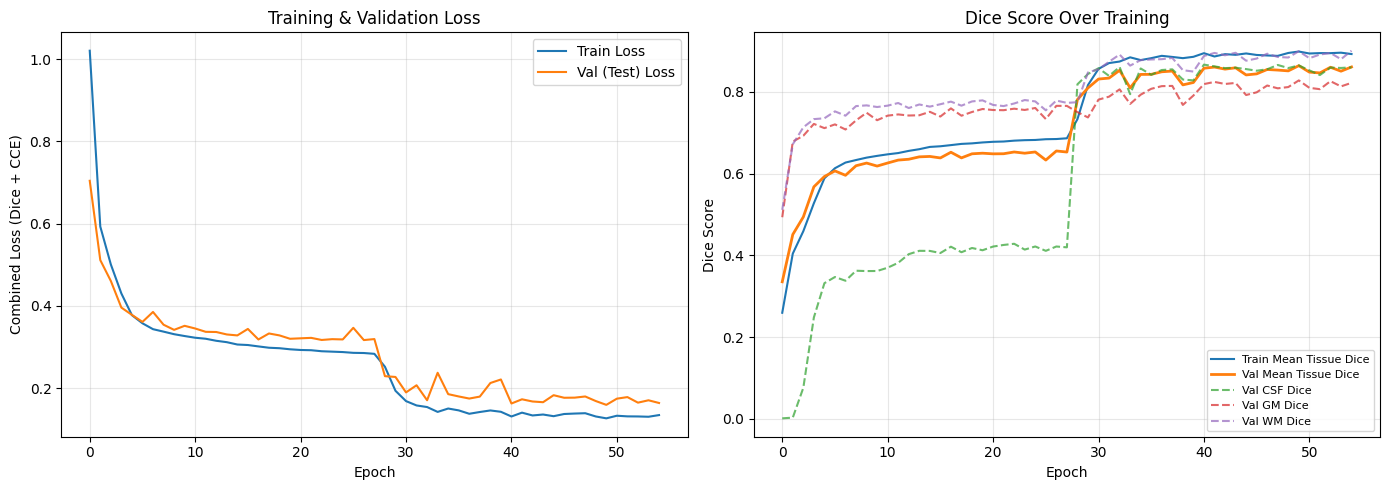

Best epoch: 50
  Val Mean Tissue Dice : 0.8637
  Val CSF Dice         : 0.8643
  Val GM Dice          : 0.8277
  Val WM Dice          : 0.8991
  Val Loss             : 0.1594


In [ ]:
# ============================================================
# CELL — Plot Training History (loss + Dice curves)
# ============================================================
# Loads the history saved by the training cell and plots it.
# Run this any time after training — even in a separate session,
# as long as training_history.csv exists.

import pandas as pd
import matplotlib.pyplot as plt

CKPT_DIR = "/content/checkpoints"
history_df = pd.read_csv(f"{CKPT_DIR}/training_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history_df["loss"], label="Train Loss")
axes[0].plot(history_df["val_loss"], label="Val (Test) Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Combined Loss (Dice + CCE)")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Dice curves — overall tissue dice + per-class
axes[1].plot(history_df["mean_tissue_dice"], label="Train Mean Tissue Dice")
axes[1].plot(history_df["val_mean_tissue_dice"], label="Val Mean Tissue Dice", linewidth=2)
axes[1].plot(history_df["val_csf_dice"], "--", label="Val CSF Dice", alpha=0.7)
axes[1].plot(history_df["val_gm_dice"], "--", label="Val GM Dice", alpha=0.7)
axes[1].plot(history_df["val_wm_dice"], "--", label="Val WM Dice", alpha=0.7)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].set_title("Dice Score Over Training")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

best_epoch = int(history_df["val_mean_tissue_dice"].idxmax())
print(f"Best epoch: {best_epoch+1}")
print(f"  Val Mean Tissue Dice : {history_df['val_mean_tissue_dice'][best_epoch]:.4f}")
print(f"  Val CSF Dice         : {history_df['val_csf_dice'][best_epoch]:.4f}")
print(f"  Val GM Dice          : {history_df['val_gm_dice'][best_epoch]:.4f}")
print(f"  Val WM Dice          : {history_df['val_wm_dice'][best_epoch]:.4f}")
print(f"  Val Loss             : {history_df['val_loss'][best_epoch]:.4f}")


(None, 256, 256)
(None, 256, 256)
(256,)
(256, 256)
z3 : (None, 256, 256)
z6 : (None, 256, 256)
z9 : (None, 256, 256)
z3 : (None, 16, 16, 256)
test
z0 shape:  (None, 256, 256, 32)
x shape:  (None, 256, 256, 32)
output shape:  (None, 256, 256, 4)
Loaded best weights from /content/checkpoints/best_model.weights.h5


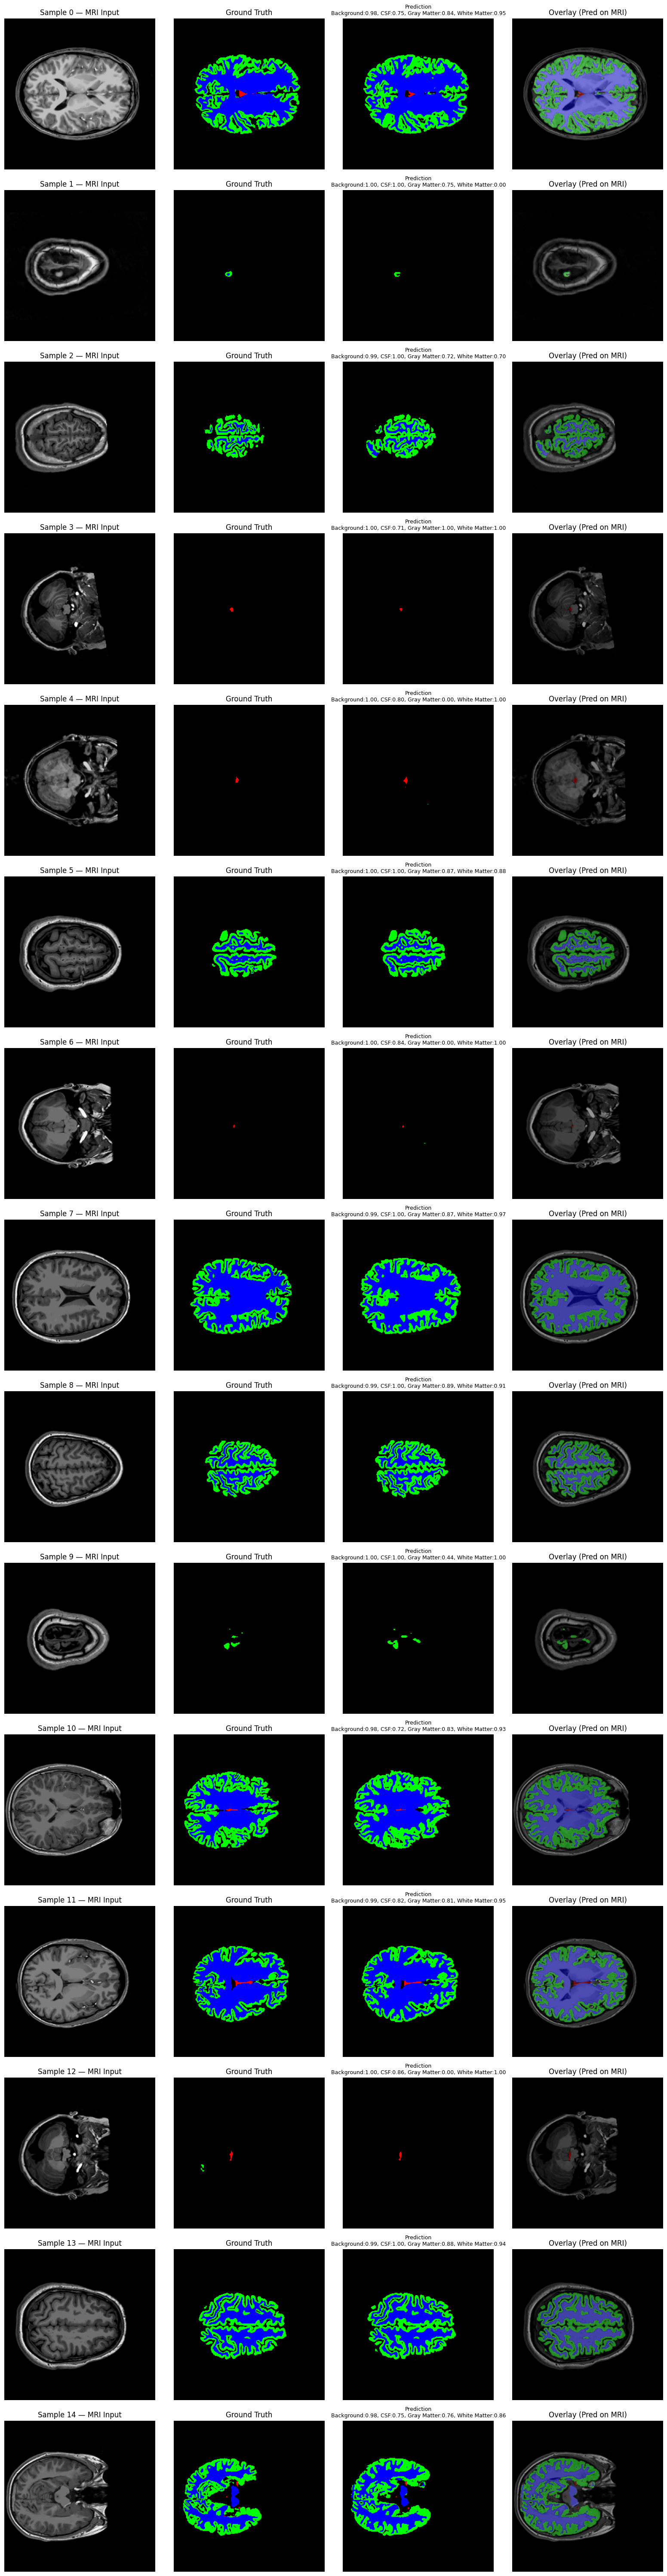


✅ Visual results saved to /content/checkpoints/visual_test_results.png
Legend: Black=Background, Red=CSF, Green=Gray Matter, Blue=White Matter

=== Final Test Set Dice (mean over all test slices) ===
  Background     : 0.9906
  CSF            : 0.7884
  Gray Matter    : 0.7785
  White Matter   : 0.8582
  Tissue mean (CSF+GM+WM): 0.8084


In [ ]:
# ============================================================
# CELL — Load Best Model + Visual Testing on the Test Set
# ============================================================
#
# 1. Rebuilds the model architecture and loads the BEST checkpoint
#    (selected by val_mean_tissue_dice during training).
# 2. Runs predictions on a handful of test-set slices.
# 3. Plots: input MRI | ground-truth mask | predicted mask | overlay
#    for each sample, color-coded by tissue class.
# 4. Also prints per-class Dice for each shown example.

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

CKPT_DIR = "/content/checkpoints"
checkpoint_path = f"{CKPT_DIR}/best_model.weights.h5"

# ── Rebuild architecture + load best weights ──────────────────
best_model = bulid_2d_unetr(config)
best_model.load_weights(checkpoint_path)
print(f"Loaded best weights from {checkpoint_path}")


# ── Helpers ──────────────────────────────────────────────────

CLASS_COLORS = np.array([
    [0,   0,   0],     # Background -> black
    [255, 0,   0],     # CSF        -> red
    [0,   255, 0],     # Gray Matter-> green
    [0,   0,   255],   # White Matter -> blue
], dtype=np.uint8)


def mask_onehot_to_rgb(mask_onehot):
    """(H, W, 4) one-hot/softmax -> (H, W, 3) RGB visualization."""
    class_idx = np.argmax(mask_onehot, axis=-1)   # (H, W)
    return CLASS_COLORS[class_idx]


def unpatchify_for_display(patched_img, image_size, patch_size, num_channels):
    """(num_patches, patch_flat) -> (H, W) grayscale image, for plotting only."""
    n = image_size // patch_size
    p = patch_size
    patches = patched_img.reshape(n, n, p, p, num_channels)
    img = patches.transpose(0, 2, 1, 3, 4).reshape(image_size, image_size, num_channels)
    return img[..., 0]  # single channel, grayscale


def dice_score_np(y_true, y_pred_onehot, smooth=1e-6):
    """Per-class Dice for a single (H, W, 4) pair, numpy version, for printing."""
    dice = []
    for c in range(y_true.shape[-1]):
        inter = np.sum(y_true[..., c] * y_pred_onehot[..., c])
        union = np.sum(y_true[..., c]) + np.sum(y_pred_onehot[..., c])
        dice.append((2 * inter + smooth) / (union + smooth))
    return np.array(dice)


# ── Pick a few test samples and visualize ─────────────────────

N_EXAMPLES = 15
CLASS_NAMES = ["Background", "CSF", "Gray Matter", "White Matter"]

# Pull N_EXAMPLES batches' worth of single samples from test_ds
test_iter = iter(
    test_ds.unbatch()
           .shuffle(1000)
           .take(N_EXAMPLES)
)
fig, axes = plt.subplots(N_EXAMPLES, 4, figsize=(16, 4 * N_EXAMPLES))

for idx, (img_patched, mask_true) in enumerate(test_iter):
    img_patched_np = img_patched.numpy()
    mask_true_np = mask_true.numpy()

    # model expects a batch dimension
    pred = best_model.predict(img_patched_np[np.newaxis, ...], verbose=0)[0]  # (H, W, 4)
    pred_onehot = np.eye(4, dtype=np.float32)[np.argmax(pred, axis=-1)]       # hard prediction

    mri_display = unpatchify_for_display(
        img_patched_np, config["image_size"], config["patch_size"], config["num_channels"]
    )

    gt_rgb = mask_onehot_to_rgb(mask_true_np)
    pred_rgb = mask_onehot_to_rgb(pred)

    # overlay: prediction mask blended over the MRI
    mri_rgb = np.stack([mri_display]*3, axis=-1)
    mri_rgb = (mri_rgb - mri_rgb.min()) / (mri_rgb.max() - mri_rgb.min() + 1e-6)
    overlay = 0.6 * mri_rgb + 0.4 * (pred_rgb.astype(np.float32) / 255.0)
    overlay = np.clip(overlay, 0, 1)

    dice_scores = dice_score_np(mask_true_np, pred_onehot)

    axes[idx, 0].imshow(mri_display, cmap="gray")
    axes[idx, 0].set_title(f"Sample {idx} — MRI Input")
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(gt_rgb)
    axes[idx, 1].set_title("Ground Truth")
    axes[idx, 1].axis("off")

    axes[idx, 2].imshow(pred_rgb)
    dice_str = ", ".join(f"{n}:{d:.2f}" for n, d in zip(CLASS_NAMES, dice_scores))
    axes[idx, 2].set_title(f"Prediction\n{dice_str}", fontsize=9)
    axes[idx, 2].axis("off")

    axes[idx, 3].imshow(overlay)
    axes[idx, 3].set_title("Overlay (Pred on MRI)")
    axes[idx, 3].axis("off")

plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/visual_test_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Visual results saved to {CKPT_DIR}/visual_test_results.png")
print("Legend: Black=Background, Red=CSF, Green=Gray Matter, Blue=White Matter")


# ── Aggregate Dice over the FULL test set (not just the shown examples) ──

all_dice = []
for img_patched, mask_true in test_ds.unbatch():
    pred = best_model.predict(img_patched.numpy()[np.newaxis, ...], verbose=0)[0]
    pred_onehot = np.eye(4, dtype=np.float32)[np.argmax(pred, axis=-1)]
    all_dice.append(dice_score_np(mask_true.numpy(), pred_onehot))

all_dice = np.array(all_dice)  # (num_test_samples, 4)
mean_dice_per_class = all_dice.mean(axis=0)

print("\n=== Final Test Set Dice (mean over all test slices) ===")
for name, score in zip(CLASS_NAMES, mean_dice_per_class):
    print(f"  {name:15s}: {score:.4f}")
print(f"  {'Tissue mean (CSF+GM+WM)':15s}: {mean_dice_per_class[1:].mean():.4f}")
